In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sqlalchemy import create_engine

import mysql.connector
import urllib.parse
import os
from dotenv import load_dotenv

In [2]:
df = pd.read_csv('customer_shopping_behavior.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
df.describe(include = 'all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
# we'll replace the null values with mean or median.
# generally we should choose median over mean as mean often gets affected by outliers, which would skew the distribution of our data.
# however, median is more robust to outliers and would give us a better representation of the central tendency of our data.
# for the best practice, here for the review rating column, we will not take the overall median
# instead we will work smart and take the median review rating within each product category, as different product categories may have different review rating distributions.
# and replace that with the missing values in the review rating column.

In [7]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
# we will do snake casing for all the column names for better readability and consistency, without running into errors.

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [11]:
# create a new column age_group

labels = ['Young Adult', 'Adult', 'Middle Aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)

In [12]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle Aged
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged
5,46,Middle Aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle Aged


In [13]:
# create a column purchase_frequency_days which will transform the textual data information in frequency_of_purchases column

frequency_mapping = {
    'Fortnightly': 14,
    'Bi-Weekly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [14]:
df[['frequency_of_purchases', 'purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [15]:
df[['discount_applied', 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [16]:
# now we will check whether both the discount_applied and promo_code_used columns are useful or any one of them is redundant and can be dropped without losing much information.

In [17]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [18]:
# this means that both the columns are exactly the same, so we can drop one of them without losing any information. We will drop the promo_code_used column.

In [19]:
df = df.drop('promo_code_used', axis=1)

In [20]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [21]:
from dotenv import load_dotenv
import os
import mysql.connector
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

load_dotenv()  # loads everything from .env

# Normal MySQL connector — safe even with @
conn = mysql.connector.connect(
    host=os.getenv("MYSQL_HOST"),
    user=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    database=os.getenv("MYSQL_DB")
)

# ---- FIX STARTS HERE ----

# Encode password to avoid breaking the URL
encoded_password = urllib.parse.quote_plus(os.getenv("MYSQL_PASSWORD"))

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{encoded_password}@{os.getenv('MYSQL_HOST')}/{os.getenv('MYSQL_DB')}"
)

# ---- FIX ENDS HERE ----

# write the dataframe to the MySQL database
table_name = 'customer'
df.to_sql(name=table_name, con=engine, if_exists='replace', index=False)

# read back sample
pd.read_sql("SELECT * FROM customer LIMIT 5", con=engine)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle Aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle Aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle Aged,365


In [ ]:
# Add Behavioral Features

# Average order value proxy - This estimates the average amount spent per order.
df['avg_order_value'] = df['purchase_amount'] / (df['previous_purchases'] + 1)

# Customer lifetime value proxy
df['customer_ltv_proxy'] = df['purchase_amount'] * (df['previous_purchases'] + 1)

# Purchase frequency per year
df['purchases_per_year'] = 365 / df['purchase_frequency_days']

df[['avg_order_value','customer_ltv_proxy','purchases_per_year']].head()

,avg_order_value,customer_ltv_proxy,purchases_per_year
0,3.533333,795,26.071429
1,21.333333,192,26.071429
2,3.041667,1752,52.142857
3,1.800000,4500,52.142857
4,1.531250,1568,1.000000


In [ ]:
# Why we are doing this

# Raw transactional data does not always directly tell us 
# how valuable a customer is or how often they purchase.

# Therefore we create derived behavioral metrics that 
# help measure customer value and engagement.

# Feature engineering like this is common in customer
# analytics and e-commerce platforms such as Amazon.

In [23]:
# Add Revenue Concentration Analysis

revenue_by_segment = (
    df.groupby('age_group')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

revenue_share = revenue_by_segment / revenue_by_segment.sum() * 100

pd.DataFrame({
    'Revenue': revenue_by_segment,
    'Revenue %': revenue_share.round(2)
})

C:\Users\sayon\AppData\Local\Temp\ipykernel_17452\2127734494.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount']


,Revenue,Revenue %
age_group,,
Young Adult,62143,26.66
Middle Aged,59197,25.40
Adult,55978,24.02
Senior,55763,23.92


In [ ]:
# Why we are doing this

# Businesses want to know:

# Which customer segments drive the most revenue?

# Revenue is often not evenly distributed across customers.

# Understanding revenue concentration helps companies:

# prioritize marketing efforts

# target profitable segments

# optimize product strategy.

In [24]:
# Add Customer Value Segmentation

df['customer_value_segment'] = pd.qcut(
    df['purchase_amount'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

df['customer_value_segment'].value_counts()

customer_value_segment
Medium Value    1303
Low Value       1300
High Value      1297
Name: count, dtype: int64

In [ ]:
# Why we are doing this

# Not all customers contribute equally.

# We segment customers into value tiers so we can analyze:

# high-value customers

# medium-value customers

# low-value customers.

# This is called customer segmentation, widely used in marketing and product analytics.

In [ ]:
# The Simple A/B Test

subscribers = df[df['subscription_status'] == 'Yes']['purchase_amount']
non_subscribers = df[df['subscription_status'] == 'No']['purchase_amount']

t_stat, p_value = ttest_ind(subscribers, non_subscribers)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.4368012420060051
P-value: 0.6622796924526246


In [ ]:
# The difference is not statistically significant.

# What this means
# Subscribers do NOT spend significantly more than non-subscribers in this dataset.

# Important insight

# This is actually a good analytical result, because:
# It prevents a false business conclusion.


# A two-sample t-test was conducted to compare spending between subscribers and 
# non-subscribers. The results (p = 0.662) indicate no statistically significant
# difference in spending between the two groups. This suggests that subscription 
# status alone may not strongly influence purchase amount.

In [ ]:
# Why we are doing this

# Companies often test new product features using A/B experiments.

# Example:

# Amazon launches Prime subscription.

# They want to test:

# Do Prime users spend more money?

# This analysis simulates that experiment.

In [ ]:
# Groups in the experiment

# Group A (Control group)

# Non-subscribers

# Group B (Treatment group)

# Subscribers
# Hypothesis Testing

# Null Hypothesis (H₀)

# Subscribers and non-subscribers spend the same amount.

# Alternative Hypothesis (H₁)

# Subscribers spend more.

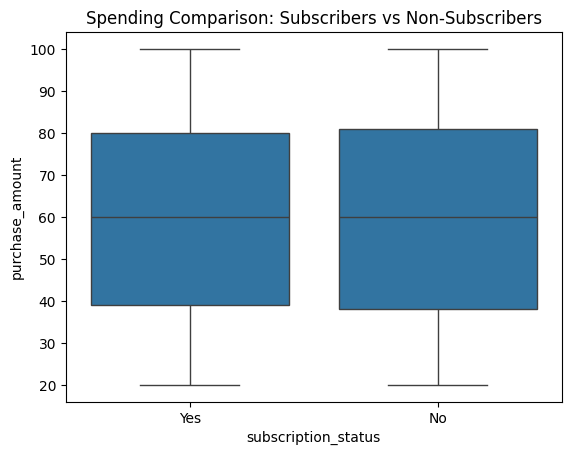

In [ ]:
# Visualize the Experiment

sns.boxplot(
    x='subscription_status',
    y='purchase_amount',
    data=df
)

plt.title("Spending Comparison: Subscribers vs Non-Subscribers")
plt.show()

In [ ]:
# The boxplot comparison shows similar spending distributions for 
# subscribers and non-subscribers, reinforcing the statistical test 
# result that subscription status does not significantly impact 
# purchase amount.

In [ ]:
# Why we visualize

# Statistical tests give numbers, but visualizations make patterns easier to understand.

# A boxplot shows

# median spending

# spread of purchases

# outliers.

# This allows us to quickly compare spending distributions between:

# subscribers

# non-subscribers.

In [27]:
# Add Pareto Revenue Analysis

customer_revenue = (
    df.groupby('customer_id')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

top_20_percent = int(len(customer_revenue) * 0.2)

top_revenue_share = (
    customer_revenue.head(top_20_percent).sum() /
    customer_revenue.sum()
)

print("Top 20% customers generate:",
      round(top_revenue_share*100,2), "% of revenue")

Top 20% customers generate: 30.99 % of revenue


In [ ]:
# Pareto analysis shows that the top 20% of customers contribute 
# approximately 31% of total revenue. This indicates that revenue 
# is relatively distributed across the customer base rather than 
# being dominated by a small set of high-value customers.

In [ ]:
# Why we are doing this

# Many businesses follow the Pareto Principle (80/20 rule):

# A small percentage of customers generate the majority of revenue.

# This analysis checks whether revenue is concentrated among top customers.

In [28]:
# Baseline Revenue

# First calculate current revenue.

total_revenue = df['purchase_amount'].sum()
print("Current total revenue:", total_revenue)

Current total revenue: 233081


In [ ]:
# Calculate total revenue generated by all transactions.
# This serves as the baseline metric that future revenue 
# simulations will be compared against.

In [ ]:
# Why we do this

# We need a baseline to compare future scenarios.

# Companies always measure before vs after.

In [29]:
# Current Subscriber Share

subscriber_rate = (df['subscription_status'] == 'Yes').mean()

print("Current subscription rate:", round(subscriber_rate*100,2), "%")

Current subscription rate: 27.0 %


In [ ]:
# Why we do this
# We measure how many customers are currently subscribed.

# Calculate the proportion of customers who are subscribed.
# This helps measure adoption of the subscription program in 
# the current customer base.

In [30]:
# Average Spend by Group

spend_by_group = df.groupby('subscription_status')['purchase_amount'].mean()

print(spend_by_group)

subscription_status
No     59.865121
Yes    59.491928
Name: purchase_amount, dtype: float64


In [ ]:
# Calculate average purchase amount for subscribers and 
# non-subscribers.
# This helps determine whether subscription status influences 
# customer spending behavior.

In [31]:
# Revenue Impact Simulation

# Now simulate increasing subscription adoption.

# Example scenario:

# Increase subscriber rate from 27% → 40%

new_subscriber_rate = 0.40

avg_sub_spend = spend_by_group['Yes']
avg_non_sub_spend = spend_by_group['No']

total_customers = len(df)

expected_revenue = (
    total_customers * new_subscriber_rate * avg_sub_spend +
    total_customers * (1-new_subscriber_rate) * avg_non_sub_spend
)

print("Projected revenue:", round(expected_revenue,2))

Projected revenue: 232891.79


In [32]:
# Revenue Lift

revenue_lift = expected_revenue - total_revenue

print("Projected revenue change:", round(revenue_lift,2))

Projected revenue change: -189.21


In [ ]:
# This shows:
# How much revenue could increase (or decrease)

In [ ]:
# Business interpretation:

# Increasing subscription adoption does not significantly affect revenue.

# This suggests:

# The subscription program likely focuses on:

# convenience
# customer retention
# loyalty
# rather than increasing purchase amount.

In [ ]:
# To evaluate the potential impact of increasing subscription adoption, 
# a revenue simulation was conducted.

# The current subscription rate in the dataset is approximately 27%, 
# with subscribers and non-subscribers showing nearly identical average 
# spending levels (~$59 per transaction).

# A simulated increase in subscription adoption to 40% resulted in minimal 
# change in projected revenue (−$189 or −0.08%).

# This suggests that subscription programs in this dataset may primarily 
# influence customer engagement or retention rather than immediate spending 
# behavior.

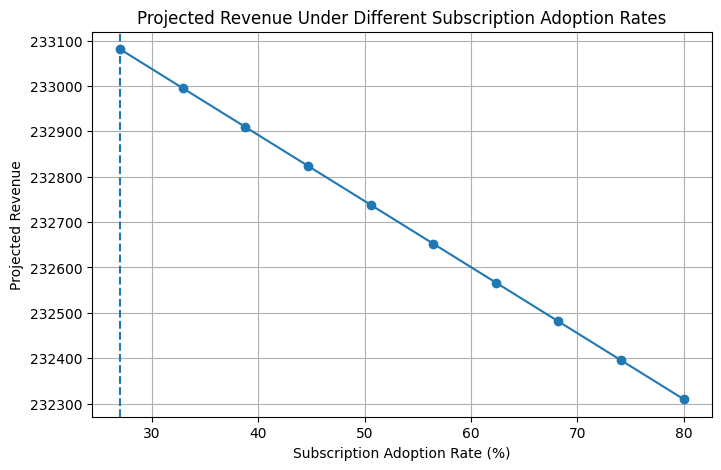

In [ ]:
# Subscription adoption vs projected revenue

# Average spend by group
avg_sub_spend = df[df['subscription_status']=='Yes']['purchase_amount'].mean()
avg_non_sub_spend = df[df['subscription_status']=='No']['purchase_amount'].mean()

# Total customers
total_customers = len(df)

# Subscription rate scenarios
subscription_rates = np.linspace(0.27, 0.80, 10)

projected_revenues = []

for rate in subscription_rates:
    
    revenue = (
        total_customers * rate * avg_sub_spend +
        total_customers * (1-rate) * avg_non_sub_spend
    )
    
    projected_revenues.append(revenue)

# Plot
plt.figure(figsize=(8,5))

plt.plot(subscription_rates*100, projected_revenues, marker='o')

plt.axvline(x=27, linestyle='--')

plt.title("Projected Revenue Under Different Subscription Adoption Rates")

plt.xlabel("Subscription Adoption Rate (%)")
plt.ylabel("Projected Revenue")

plt.grid(True)

plt.show()

In [ ]:
# A revenue scenario simulation was conducted to estimate the 
# impact of increasing subscription adoption. The analysis 
# projects revenue under different subscription adoption rates 
# ranging from 27% to 80%. Results indicate minimal revenue 
# variation as adoption increases, suggesting that subscription 
# status has limited influence on purchase amount in this dataset.